============================================================
 Titanic Survival Prediction — Full Pipeline
 Intermediate Data Science Project
 Tools: pandas, numpy, matplotlib, seaborn, scikit-learn
============================================================


── 0. Install dependencies (uncomment if needed) ──────────
!pip install pandas numpy matplotlib seaborn scikit-learn


In [58]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# ── Plot style ─────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13})



============================================================
1. LOAD DATA
============================================================


In [59]:
print("=" * 60)
print("1. LOADING DATA")
print("=" * 60)

# Load directly from the public Titanic CSV hosted by Kaggle/GitHub
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

try:
    df = pd.read_csv(URL)
    print(f"  ✓ Loaded from URL  →  {df.shape[0]} rows × {df.shape[1]} cols")
except Exception:
    # Fallback: load seaborn's built-in titanic dataset
    df_raw = sns.load_dataset("titanic")
    # Rename to match Kaggle column names
    col_map = {
        "survived": "Survived", "pclass": "Pclass", "sex": "Sex",
        "age": "Age", "sibsp": "SibSp", "parch": "Parch",
        "fare": "Fare", "embarked": "Embarked", "who": "Who",
        "deck": "Deck", "embark_town": "Embark_town"
    }
    df_raw.rename(columns=col_map, inplace=True)
    df = df_raw.copy()
    print(f"  ✓ Loaded from seaborn  →  {df.shape[0]} rows × {df.shape[1]} cols")

print(df.head())



1. LOADING DATA
  ✓ Loaded from URL  →  891 rows × 12 cols
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        

============================================================
2. DATA CLEANING
============================================================


In [60]:
print("\n" + "=" * 60)
print("2. DATA CLEANING")
print("=" * 60)




2. DATA CLEANING


### 2a. Missing values overview


In [61]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing": missing, "Pct (%)": missing_pct})
missing_df = missing_df[missing_df["Missing"] > 0].sort_values("Pct (%)", ascending=False)
print("\nMissing values:\n", missing_df)




Missing values:
           Missing  Pct (%)
Cabin         687    77.10
Age           177    19.87
Embarked        2     0.22


### 2b. Fill Age with median grouped by Pclass & Sex


In [62]:
if "Age" in df.columns:
    df["Age"] = df.groupby(["Pclass", "Sex"])["Age"].transform(
        lambda x: x.fillna(x.median())
    )
    print(f"\n  ✓ Age NaNs after fill: {df['Age'].isnull().sum()}")




  ✓ Age NaNs after fill: 0


### 2c. Fill Embarked with mode


In [63]:
if "Embarked" in df.columns:
    df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)



### 2d. Drop Cabin (too sparse), Name, Ticket, PassengerId (not predictive)


In [64]:
drop_cols = [c for c in ["Cabin", "Name", "Ticket", "PassengerId"] if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"  ✓ Dropped columns: {drop_cols}")



  ✓ Dropped columns: ['Cabin', 'Name', 'Ticket', 'PassengerId']


### 2e. Drop any remaining rows with NaN


In [65]:
before = len(df)
df.dropna(inplace=True)
print(f"  ✓ Rows removed by dropna: {before - len(df)}")
print(f"  ✓ Final shape: {df.shape}")



  ✓ Rows removed by dropna: 0
  ✓ Final shape: (891, 8)


============================================================
3. FEATURE ENGINEERING
============================================================


In [66]:
print("\n" + "=" * 60)
print("3. FEATURE ENGINEERING")
print("=" * 60)




3. FEATURE ENGINEERING


### Family size


In [67]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)



### Age bands


In [68]:
df["AgeBand"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                        labels=["Child", "Teen", "Young Adult", "Adult", "Senior"])



### Fare bands


In [69]:
df["FareBand"] = pd.qcut(df["Fare"], q=4, labels=["Low", "Mid", "High", "Very High"])



### Encode categorical columns


In [70]:
le = LabelEncoder()
for col in ["Sex", "Embarked", "AgeBand", "FareBand"]:
    if col in df.columns:
        df[col + "_enc"] = le.fit_transform(df[col].astype(str))

print("  New features: FamilySize, IsAlone, AgeBand, FareBand + encoded versions")
print(df[["Survived", "Sex", "FamilySize", "IsAlone", "AgeBand", "FareBand"]].head())



  New features: FamilySize, IsAlone, AgeBand, FareBand + encoded versions
   Survived     Sex  FamilySize  IsAlone      AgeBand   FareBand
0         0    male           2        0  Young Adult        Low
1         1  female           2        0        Adult  Very High
2         1  female           1        1  Young Adult        Mid
3         1  female           2        0  Young Adult  Very High
4         0    male           1        1  Young Adult        Mid


============================================================
4. EXPLORATORY DATA ANALYSIS (EDA) + VISUALIZATIONS
============================================================



4. EDA & VISUALIZATIONS
  ✓ EDA plots saved → titanic_eda.png


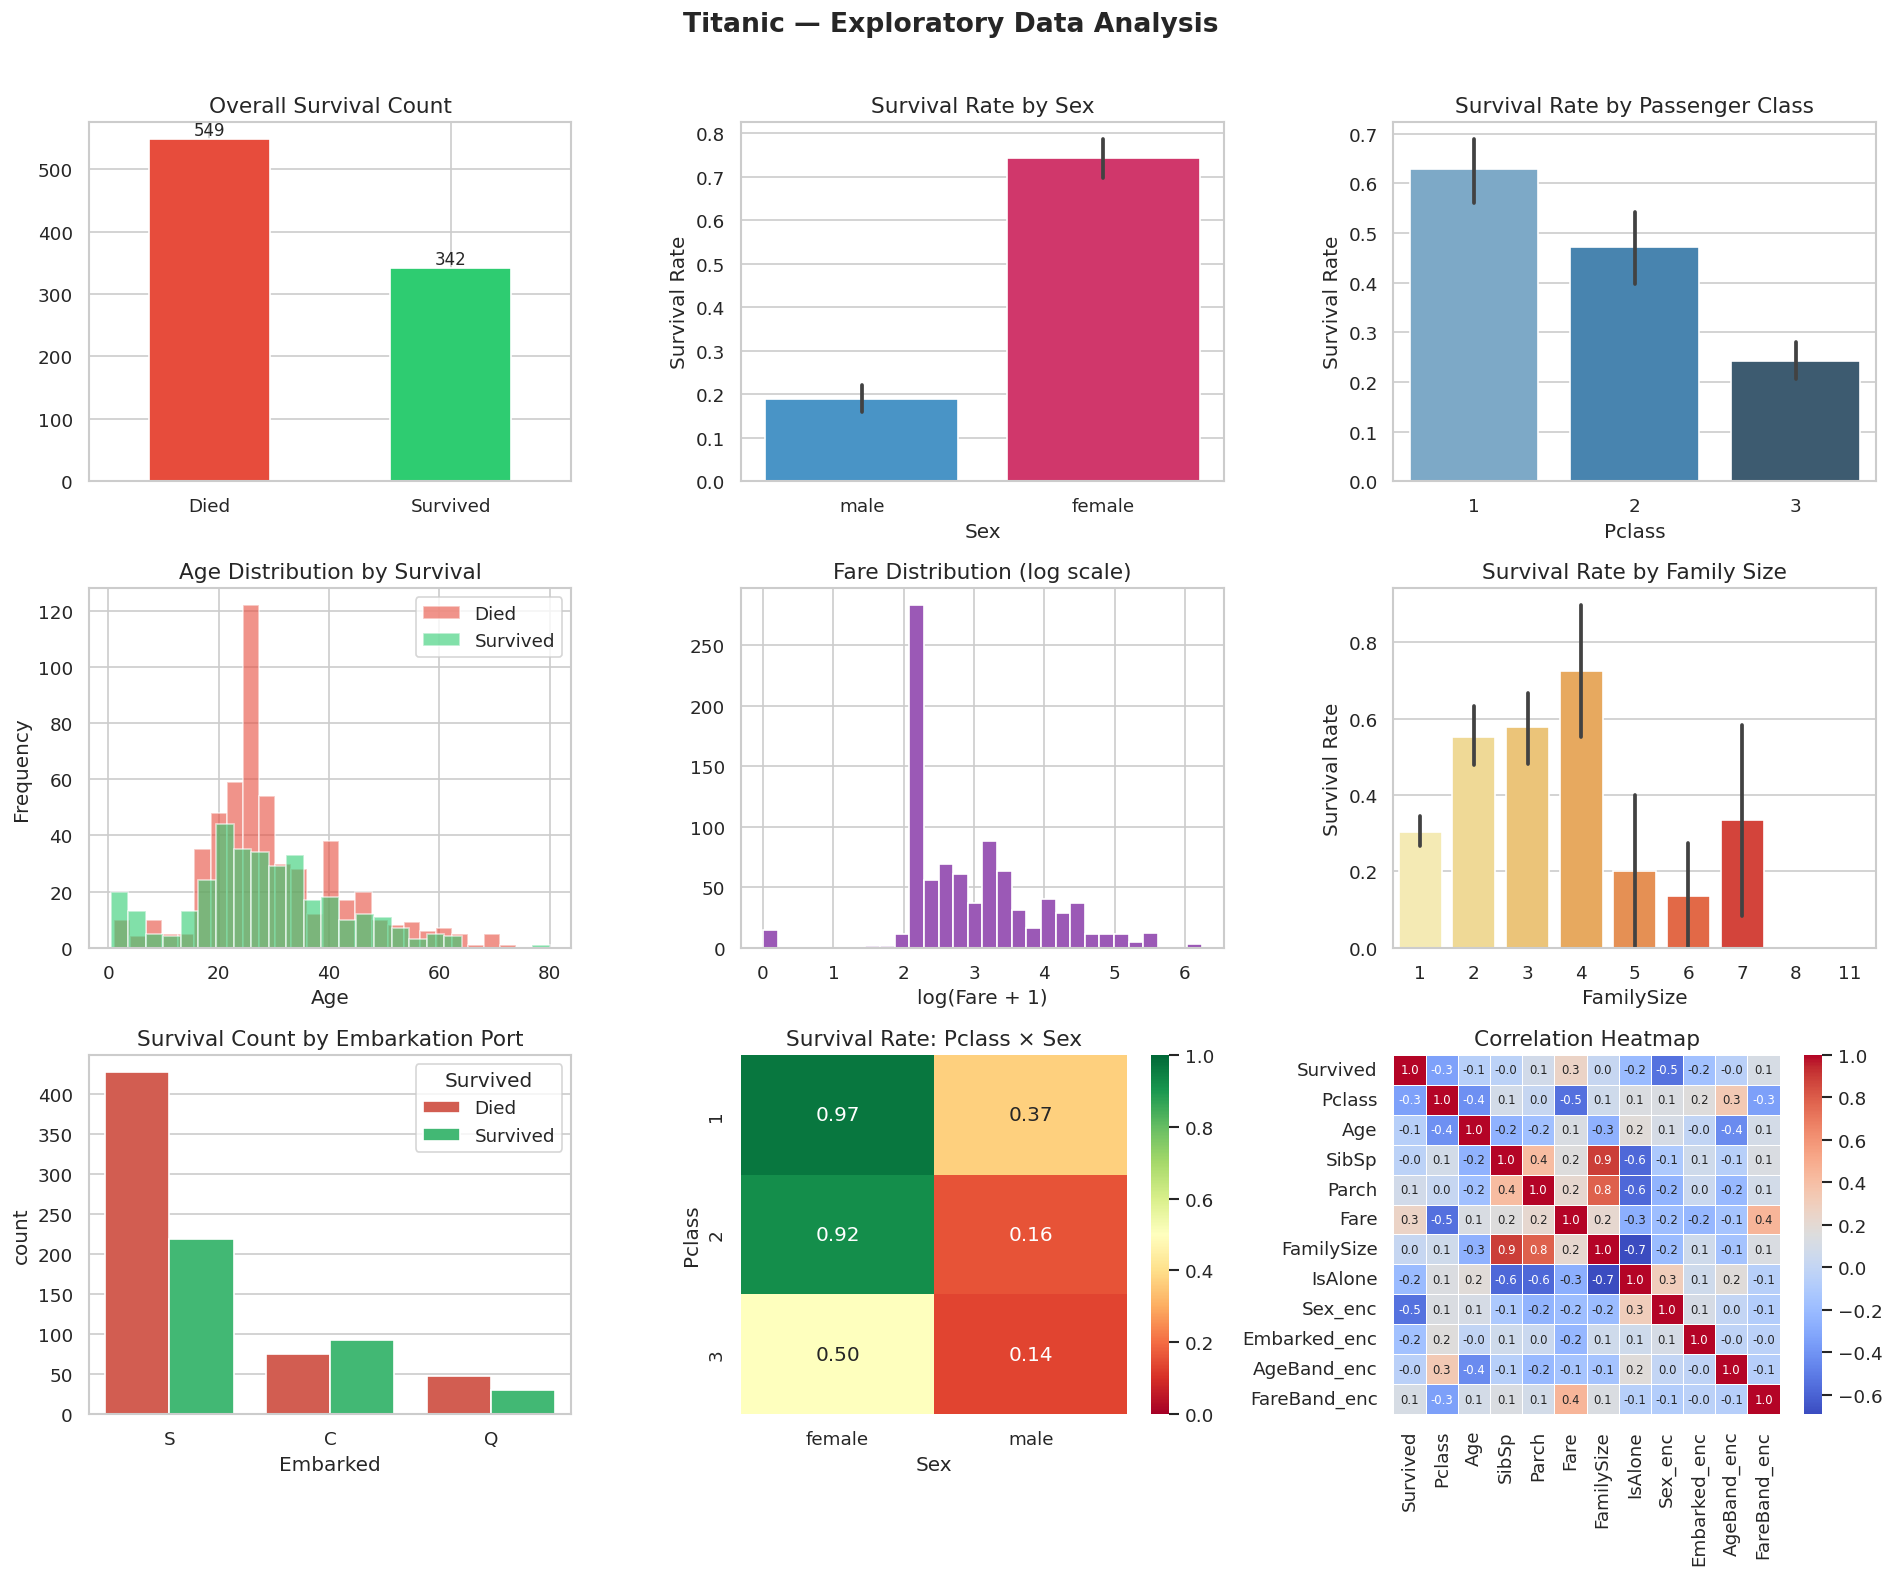

In [71]:
print("\n" + "=" * 60)
print("4. EDA & VISUALIZATIONS")
print("=" * 60)

survived_col = "Survived"
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle("Titanic — Exploratory Data Analysis", fontsize=16, fontweight="bold", y=1.01)

# 4-1  Survival count
ax = axes[0, 0]
df[survived_col].value_counts().rename({0: "Died", 1: "Survived"}).plot(
    kind="bar", color=["#e74c3c", "#2ecc71"], ax=ax, edgecolor="white")
ax.set_title("Overall Survival Count")
ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

# 4-2  Survival by Sex
ax = axes[0, 1]
sns.barplot(data=df, x="Sex", y=survived_col, palette=["#3498db", "#e91e63"], ax=ax)
ax.set_title("Survival Rate by Sex")
ax.set_ylabel("Survival Rate")

# 4-3  Survival by Pclass
ax = axes[0, 2]
sns.barplot(data=df, x="Pclass", y=survived_col, palette="Blues_d", ax=ax)
ax.set_title("Survival Rate by Passenger Class")
ax.set_ylabel("Survival Rate")

# 4-4  Age distribution
ax = axes[1, 0]
for s, color, label in [(0, "#e74c3c", "Died"), (1, "#2ecc71", "Survived")]:
    df[df[survived_col] == s]["Age"].plot(
        kind="hist", bins=25, alpha=0.6, color=color, label=label, ax=ax)
ax.set_title("Age Distribution by Survival")
ax.set_xlabel("Age"); ax.legend()

# 4-5  Fare distribution (log scale)
ax = axes[1, 1]
df["Fare"].apply(lambda x: np.log1p(x)).hist(bins=30, color="#9b59b6", edgecolor="white", ax=ax)
ax.set_title("Fare Distribution (log scale)")
ax.set_xlabel("log(Fare + 1)")

# 4-6  Family size vs Survival
ax = axes[1, 2]
sns.barplot(data=df, x="FamilySize", y=survived_col, palette="YlOrRd", ax=ax)
ax.set_title("Survival Rate by Family Size")
ax.set_ylabel("Survival Rate")

# 4-7  Embarked vs Survival
ax = axes[2, 0]
sns.countplot(data=df, x="Embarked", hue=survived_col,
              palette={0: "#e74c3c", 1: "#2ecc71"}, ax=ax)
ax.set_title("Survival Count by Embarkation Port")
ax.legend(title="Survived", labels=["Died", "Survived"])

# 4-8  Pclass × Sex heatmap
ax = axes[2, 1]
pivot = df.groupby(["Pclass", "Sex"])[survived_col].mean().unstack()
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax, vmin=0, vmax=1)
ax.set_title("Survival Rate: Pclass × Sex")

# 4-9  Correlation heatmap (numeric features)
ax = axes[2, 2]
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".1f", cmap="coolwarm", ax=ax,
            annot_kws={"size": 7}, linewidths=0.4)
ax.set_title("Correlation Heatmap")

plt.tight_layout()
print("  ✓ EDA plots saved → titanic_eda.png")
plt.show()



============================================================
5. MODEL BUILDING
============================================================


In [72]:
print("\n" + "=" * 60)
print("5. MODEL BUILDING")
print("=" * 60)




5. MODEL BUILDING


### Feature selection


In [73]:
feature_cols = [
    "Pclass", "Sex_enc", "Age", "SibSp", "Parch",
    "Fare", "Embarked_enc", "FamilySize", "IsAlone",
    "AgeBand_enc", "FareBand_enc"
]
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols]
y = df[survived_col]

print(f"  Features used: {feature_cols}")
print(f"  X shape: {X.shape}  |  Class balance: {y.value_counts().to_dict()}")



  Features used: ['Pclass', 'Sex_enc', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_enc', 'FamilySize', 'IsAlone', 'AgeBand_enc', 'FareBand_enc']
  X shape: (891, 11)  |  Class balance: {0: 549, 1: 342}


### Train / test split


In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)



### Scale


In [75]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)



### Models


In [76]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, random_state=42),
}

results = {}
print("\n  5-Fold Cross-Validation Accuracy:")
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_sc, y_train, cv=5, scoring="accuracy")
    results[name] = {"cv_mean": cv_scores.mean(), "cv_std": cv_scores.std()}
    print(f"    {name:25s}  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")




  5-Fold Cross-Validation Accuracy:
    Logistic Regression        0.7979 ± 0.0302
    Random Forest              0.7937 ± 0.0490
    Gradient Boosting          0.8148 ± 0.0527


### Pick best model & evaluate on test set


In [77]:
best_name = max(results, key=lambda k: results[k]["cv_mean"])
best_model = models[best_name]
best_model.fit(X_train_sc, y_train)
y_pred = best_model.predict(X_test_sc)

print(f"\n  Best model: {best_name}")
print(f"  Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\n  Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Died", "Survived"]))




  Best model: Gradient Boosting
  Test Accuracy: 0.7989

  Classification Report:

              precision    recall  f1-score   support

        Died       0.80      0.89      0.84       110
    Survived       0.79      0.65      0.71        69

    accuracy                           0.80       179
   macro avg       0.80      0.77      0.78       179
weighted avg       0.80      0.80      0.79       179



============================================================
6. MODEL EVALUATION PLOTS
============================================================


6. MODEL EVALUATION PLOTS
  ✓ Model evaluation plots saved → titanic_model_eval.png


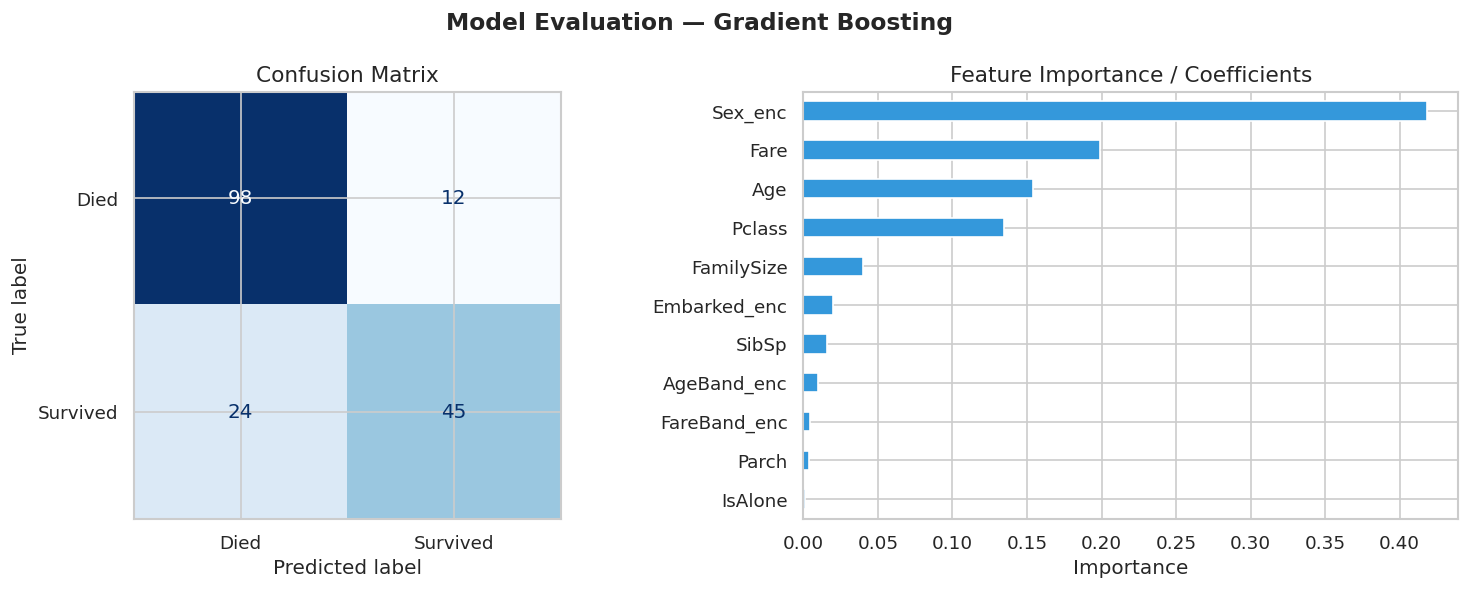

In [78]:
print("=" * 60)
print("6. MODEL EVALUATION PLOTS")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Model Evaluation — {best_name}", fontsize=14, fontweight="bold")

# 6-1  Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix")

# 6-2  Feature importance (Random Forest / GB) or coefficients (LR)
ax = axes[1]
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_cols)
else:
    importances = pd.Series(np.abs(best_model.coef_[0]), index=feature_cols)

importances.sort_values().plot(kind="barh", color="#3498db", edgecolor="white", ax=ax)
ax.set_title("Feature Importance / Coefficients")
ax.set_xlabel("Importance")

plt.tight_layout()
print("  ✓ Model evaluation plots saved → titanic_model_eval.png")
plt.show()



============================================================
7. KEY INSIGHTS
============================================================


In [79]:
print("\n" + "=" * 60)
print("7. KEY INSIGHTS")
print("=" * 60)

surv_by_sex   = df.groupby("Sex")["Survived"].mean().round(3)
surv_by_class = df.groupby("Pclass")["Survived"].mean().round(3)
surv_by_alone = df.groupby("IsAlone")["Survived"].mean().round(3)

print(f"""
  ▸ Overall survival rate  : {y.mean():.1%}
  ▸ Female survival rate   : {surv_by_sex.get('female', surv_by_sex.get('female','N/A'))}
  ▸ Male survival rate     : {surv_by_sex.get('male',   surv_by_sex.get('male', 'N/A'))}
  ▸ 1st class survival     : {surv_by_class.get(1, 'N/A')}
  ▸ 2nd class survival     : {surv_by_class.get(2, 'N/A')}
  ▸ 3rd class survival     : {surv_by_class.get(3, 'N/A')}
  ▸ Travelling alone       : {surv_by_alone.get(1, 'N/A')}
  ▸ Travelling with family : {surv_by_alone.get(0, 'N/A')}
  ▸ Best model             : {best_name}
  ▸ Test accuracy          : {accuracy_score(y_test, y_pred):.1%} """)



7. KEY INSIGHTS

  ▸ Overall survival rate  : 38.4%
  ▸ Female survival rate   : 0.742
  ▸ Male survival rate     : 0.189
  ▸ 1st class survival     : 0.63
  ▸ 2nd class survival     : 0.473
  ▸ 3rd class survival     : 0.242
  ▸ Travelling alone       : 0.304
  ▸ Travelling with family : 0.506
  ▸ Best model             : Gradient Boosting
  ▸ Test accuracy          : 79.9% 
